In [24]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


In [25]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()

# Bag recorded while rotating the IMU in a circle (for magnetometer calibration)
BAG_PATH_circle = NOTEBOOK_DIR.parents[1] / "src/data/data_going_in_circles"
# Bag recorded while driving
BAG_PATH_drive  = NOTEBOOK_DIR.parents[1] / "src/data/data_driving"

test_PATH = NOTEBOOK_DIR.parents[1] / "src/data/test1"

IMU_TOPIC = "/imu"
GPS_TOPIC = "/gps"

IMU_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/imu_msg/msg/IMUmsg.msg"
IMU_MSG_TYPE = "imu_msg/msg/IMUmsg"

GPS_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/gps_driver_msgs/msg/GpsMsg.msg"
GPS_MSG_TYPE = "gps_driver_msgs/msg/GpsMsg"

In [26]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, IMU_MSG_PATH, IMU_MSG_TYPE)
register_msg_file(typestore, GPS_MSG_PATH, GPS_MSG_TYPE)

In [27]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),
                "gyro_x":    float(msg.imu.angular_velocity.x),
                "gyro_y":    float(msg.imu.angular_velocity.y),
                "gyro_z":    float(msg.imu.angular_velocity.z),
                "accel_x":   float(msg.imu.linear_acceleration.x),
                "accel_y":   float(msg.imu.linear_acceleration.y),
                "accel_z":   float(msg.imu.linear_acceleration.z),
                "mag_x":     float(msg.mag_field.magnetic_field.x),
                "mag_y":     float(msg.mag_field.magnetic_field.y),
                "mag_z":     float(msg.mag_field.magnetic_field.z),
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"]    = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    df["timestamp"] = df["time_s"]   # alias used in analysis cells
    df["imu_yaw"]   = df["yaw_deg"]  # alias used in analysis cells
    return df


def bag_to_df_gps(bag_path, typestore, topic: str = "/gps") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)
            rows.append({
                "bag_time_ns":   int(timestamp),
                "latitude":      float(msg.latitude),
                "longitude":     float(msg.longitude),
                "altitude":      float(msg.altitude),
                "utm_easting":   float(msg.utm_easting),
                "utm_northing":  float(msg.utm_northing),
                "hdop":          float(msg.hdop),
                "utc":           str(msg.utc),
                "zone":          str(msg.zone),
            })
    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

## Load Bags into DataFrames

In [28]:
df_circle = bag_to_df_imu(BAG_PATH_circle, typestore, IMU_TOPIC)
df_circle = df_circle[df_circle['time_s'] > 4500].reset_index(drop=True)

df_drive  = bag_to_df_imu(BAG_PATH_drive,  typestore, IMU_TOPIC)
df_gps    = bag_to_df_gps(BAG_PATH_drive,  typestore, GPS_TOPIC)

df_test = bag_to_df_imu(test_PATH, typestore, IMU_TOPIC)

print(f"Circle bag: {len(df_circle)} IMU samples, {df_circle['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_drive)}  IMU samples, {df_drive['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_gps)}   GPS samples")
print(f"Test bag:   {len(df_test)}  IMU samples, {df_test['time_s'].iloc[-1]:.1f} s")

df_test

Circle bag: 106 IMU samples, 5017.2 s
Drive bag:  1258  IMU samples, 1257.0 s
Drive bag:  1255   GPS samples
Test bag:   8  IMU samples, 7.0 s


,bag_time_ns,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,roll_deg,pitch_deg,yaw_deg,time_s,timestamp,imu_yaw
0,1775226351599110104,-0.000187,0.001651,-0.001872,-1.133,7.729,6.157,-0.00003,-0.000020,-0.00001,-128.408,-6.607,-172.403,0.000000,0.000000,-172.403
1,1775226352600104569,0.002326,0.000470,-0.000771,-1.139,7.750,6.158,-0.00003,-0.000019,-0.00001,-128.411,-6.612,-172.402,1.000994,1.000994,-172.402
2,1775226353598867061,-0.001565,-0.000549,0.001777,-1.148,7.741,6.159,-0.00003,-0.000020,-0.00001,-128.401,-6.609,-172.408,1.999757,1.999757,-172.408
3,1775226354599808308,-0.000566,0.000061,0.000479,-1.133,7.764,6.130,-0.00003,-0.000020,-0.00001,-128.402,-6.609,-172.410,3.000698,3.000698,-172.410
4,1775226355599740677,0.001258,0.001157,-0.000011,-1.157,7.751,6.137,-0.00003,-0.000019,-0.00001,-128.398,-6.605,-172.405,4.000631,4.000631,-172.405
5,1775226356600563622,0.000461,0.001446,-0.000924,-1.138,7.754,6.142,-0.00003,-0.000020,-0.00001,-128.400,-6.597,-172.402,5.001454,5.001454,-172.402
6,1775226357600108068,-0.000515,0.001770,-0.000106,-1.145,7.760,6.166,-0.00003,-0.000019,-0.00001,-128.399,-6.599,-172.388,6.000998,6.000998,-172.388
7,1775226358600623087,-0.001384,0.000751,0.000720,-1.141,7.725,6.160,-0.00003,-0.000019,-0.00001,-128.401,-6.602,-172.389,7.001513,7.001513,-172.389


a) Fit a general ellipsoid to the mag_x, mag_y, mag_z data using least squares

In [29]:
mag = df_circle[["mag_x", "mag_y", "mag_z"]].values # shape (N, 3)
x, y, z = mag[:, 0], mag[:, 1], mag[:, 2]

# Build the Design matrix for the ellipsoid fit
D_mat = np.column_stack([
    x**2, y**2, z**2,
    2*x*y, 2*x*z, 2*y*z,
    2*x, 2*y, 2*z,
])

# Solve D_mat @ v = 1  (vector of ones)
ones = np.ones(len(x))
v, residuals, rank, sv = np.linalg.lstsq(D_mat, ones, rcond=None)


In [30]:
# ============================================================
# Step 2: Extract ellipsoid parameters
# 
# Reconstruct the quadric matrix Q and offset vector
# Q = [[A, D, E],    g = [G, H, I]
#      [D, B, F],
#      [E, F, C]]
# ============================================================

A_q = np.array([
    [v[0], v[3], v[4]],
    [v[3], v[1], v[5]],
    [v[4], v[5], v[2]]
])
g = np.array([v[6], v[7], v[8]])

# Hard-iron offset: center = -A_q^{-1} @ g
hard_iron = -np.linalg.inv(A_q) @ g

In [31]:

# ============================================================
# Step 3: Compute the soft-iron correction matrix
#
# We want a matrix W such that:  m_corrected = W @ (m_raw - hard_iron)
# maps the ellipsoid to a sphere of radius = local field magnitude
# ============================================================

# Eigendecompose A_q to get axes/radii
eigvals, eigvecs = np.linalg.eigh(A_q)

# The radii of the ellipsoid: r_i = 1/sqrt(eigenvalue) 
# (after accounting for the constant offset term)
# Reconstruct: the value at center is g^T A_q^{-1} g, 
# so the RHS becomes 1 + g^T @ inv(A_q) @ g
rhs = 1.0 + g @ np.linalg.inv(A_q) @ g
radii = np.sqrt(rhs / eigvals)

# Average radius (approximate local field magnitude in sensor units)
avg_radius = np.mean(radii)

# Soft-iron correction matrix: scales each eigenvector axis to avg_radius
# W = eigvecs @ diag(avg_radius / radii) @ eigvecs^T
scale = avg_radius / radii
W = eigvecs @ np.diag(scale) @ eigvecs.T

In [32]:
mag_corrected = (W @ (mag - hard_iron).T).T

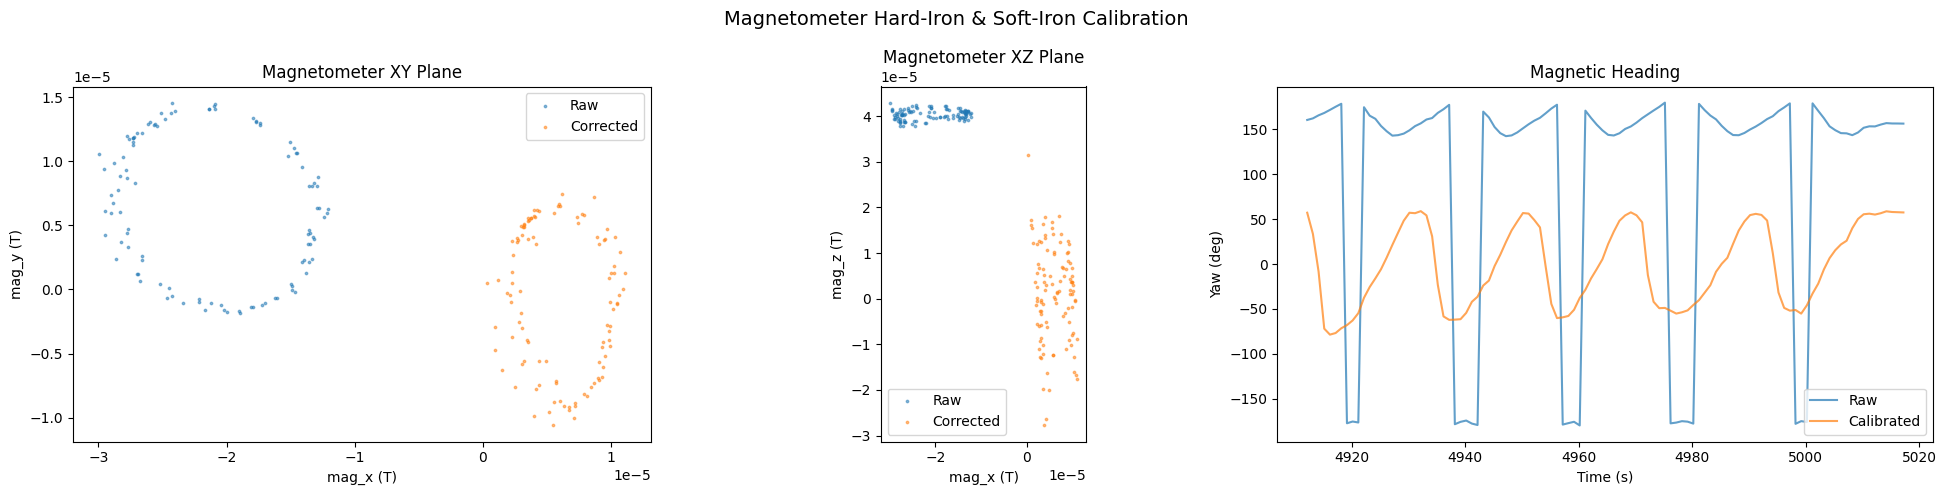

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# XY plane — most important for heading
axes[0].scatter(mag[:, 0], mag[:, 1], s=3, alpha=0.5, label='Raw')
axes[0].scatter(mag_corrected[:, 0], mag_corrected[:, 1], s=3, alpha=0.5, label='Corrected')
axes[0].set_xlabel('mag_x (T)'); axes[0].set_ylabel('mag_y (T)')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].set_title('Magnetometer XY Plane')

# XZ plane
axes[1].scatter(mag[:, 0], mag[:, 2], s=3, alpha=0.5, label='Raw')
axes[1].scatter(mag_corrected[:, 0], mag_corrected[:, 2], s=3, alpha=0.5, label='Corrected')
axes[1].set_xlabel('mag_x (T)'); axes[1].set_ylabel('mag_z (T)')
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].set_title('Magnetometer XZ Plane')

# Yaw comparison
yaw_raw = np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))
yaw_cal = np.degrees(np.arctan2(mag_corrected[:, 1], mag_corrected[:, 0]))
axes[2].plot(df_circle['time_s'], yaw_raw, label='Raw', alpha=0.7)
axes[2].plot(df_circle['time_s'], yaw_cal, label='Calibrated', alpha=0.7)
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Yaw (deg)')
axes[2].legend()
axes[2].set_title('Magnetic Heading')

plt.suptitle('Magnetometer Hard-Iron & Soft-Iron Calibration', fontsize=14)
plt.tight_layout()
plt.savefig('images/mag_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

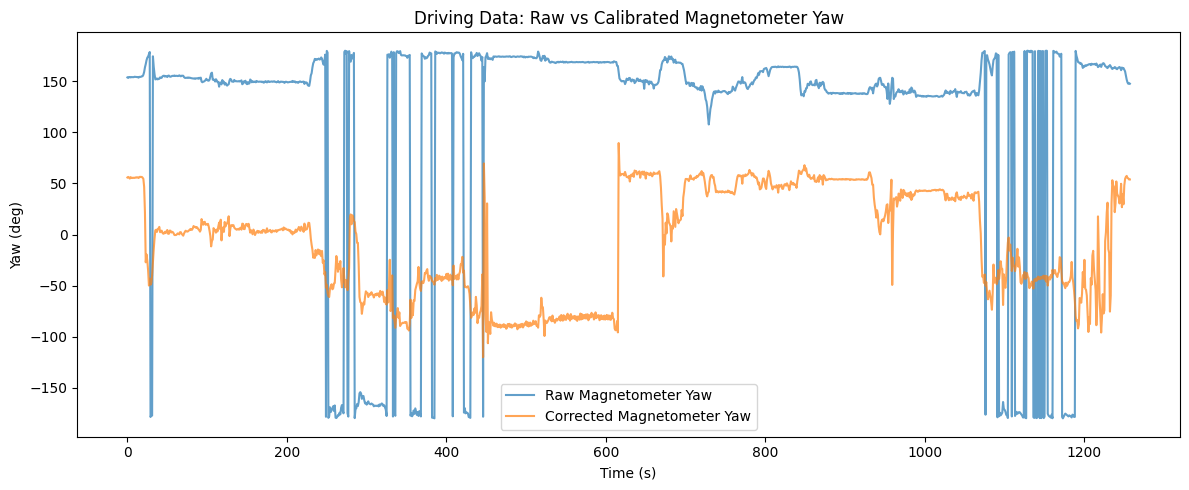

In [34]:
# Apply calibration from circle data to the driving data
mag_drive = df_drive[['mag_x', 'mag_y', 'mag_z']].values
mag_drive_corrected = (W @ (mag_drive - hard_iron).T).T

# Compute yaw from magnetometer
yaw_mag_raw = np.degrees(np.arctan2(mag_drive[:, 1], mag_drive[:, 0]))
yaw_mag_cal = np.degrees(np.arctan2(mag_drive_corrected[:, 1], mag_drive_corrected[:, 0]))

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(df_drive['time_s'], yaw_mag_raw, label='Raw Magnetometer Yaw', alpha=0.7)
plt.plot(df_drive['time_s'], yaw_mag_cal, label='Corrected Magnetometer Yaw', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Yaw (deg)')
plt.legend()
plt.title('Driving Data: Raw vs Calibrated Magnetometer Yaw')
plt.tight_layout()
plt.savefig('images/driving_mag_yaw_comparison.png', dpi=150)
plt.show()

# Store corrected yaw in the dataframe for all further analysis
df_drive['mag_yaw'] = yaw_mag_cal

## Section 1: Yaw Estimation — Sensor Fusion

**Steps:**
1. Integrate gyro_z to estimate yaw
2. Apply complementary filter (LP magnetometer + HP integrated gyro)
3. Compare all four yaw estimates: magnetometer, gyro-integrated, complementary filter, IMU Euler

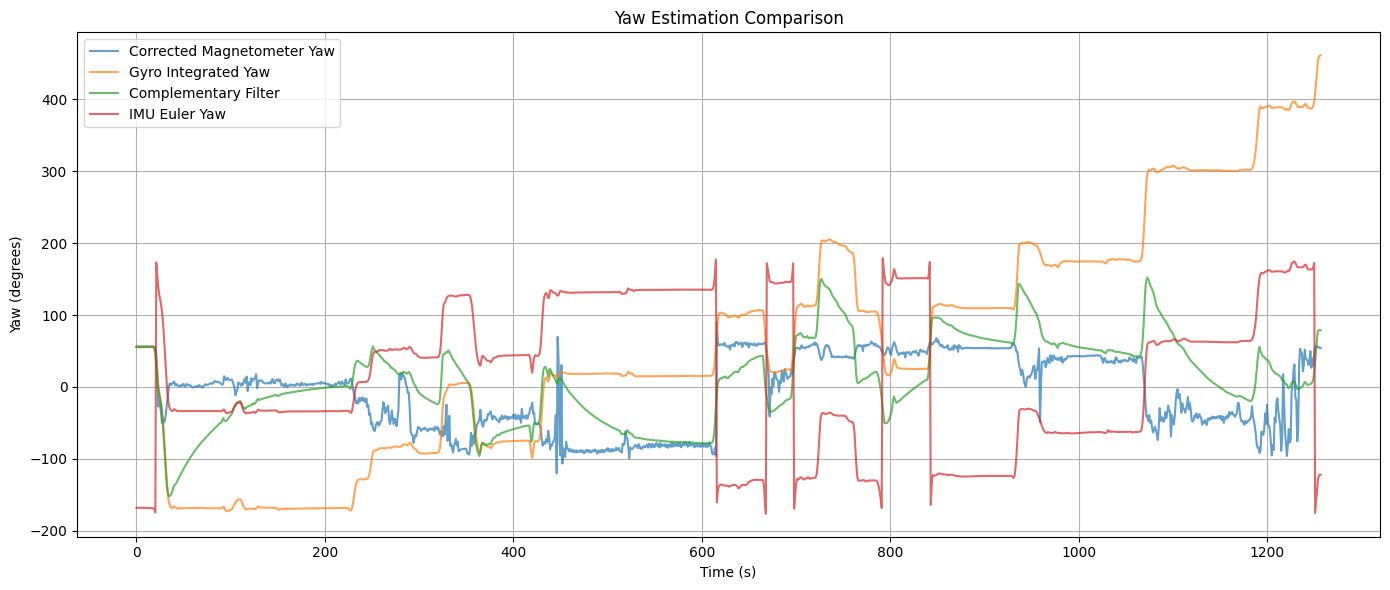

In [41]:
from scipy import integrate

# --- Gyro Yaw Integration ---
# gyro_z is in rad/s, convert to deg/s
gyro_z_deg = np.degrees(df_drive['gyro_z'].values)
time = df_drive['time_s'].values

# Cumulative trapezoidal integration
yaw_gyro = integrate.cumulative_trapezoid(gyro_z_deg, time, initial=0)

# Optional: align starting point to match corrected mag yaw
yaw_gyro += df_drive['mag_yaw'].iloc[0]

df_drive['yaw_gyro'] = yaw_gyro

# --- Complementary Filter ---
# Low-pass magnetometer + high-pass gyro
# alpha close to 1 = trust gyro more, close to 0 = trust magnetometer more
alpha = 0.98
dt = np.diff(time, prepend=time[0])

yaw_comp = np.zeros(len(df_drive))
yaw_comp[0] = df_drive['mag_yaw'].iloc[0]

for i in range(1, len(df_drive)):
    yaw_comp[i] = alpha * (yaw_comp[i-1] + gyro_z_deg[i] * dt[i]) + (1 - alpha) * df_drive['mag_yaw'].iloc[i]

df_drive['yaw_comp'] = yaw_comp

# --- Plot All Four ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time, df_drive['mag_yaw'], label='Corrected Magnetometer Yaw', alpha=0.7)
ax.plot(time, yaw_gyro, label='Gyro Integrated Yaw', alpha=0.7)
ax.plot(time, yaw_comp, label='Complementary Filter', alpha=0.7)
ax.plot(time, df_drive['imu_yaw'], label='IMU Euler Yaw', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw (degrees)')
ax.set_title('Yaw Estimation Comparison')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('images/yaw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Gyro Z bias: 0.000456 rad/s (0.0261 deg/s)


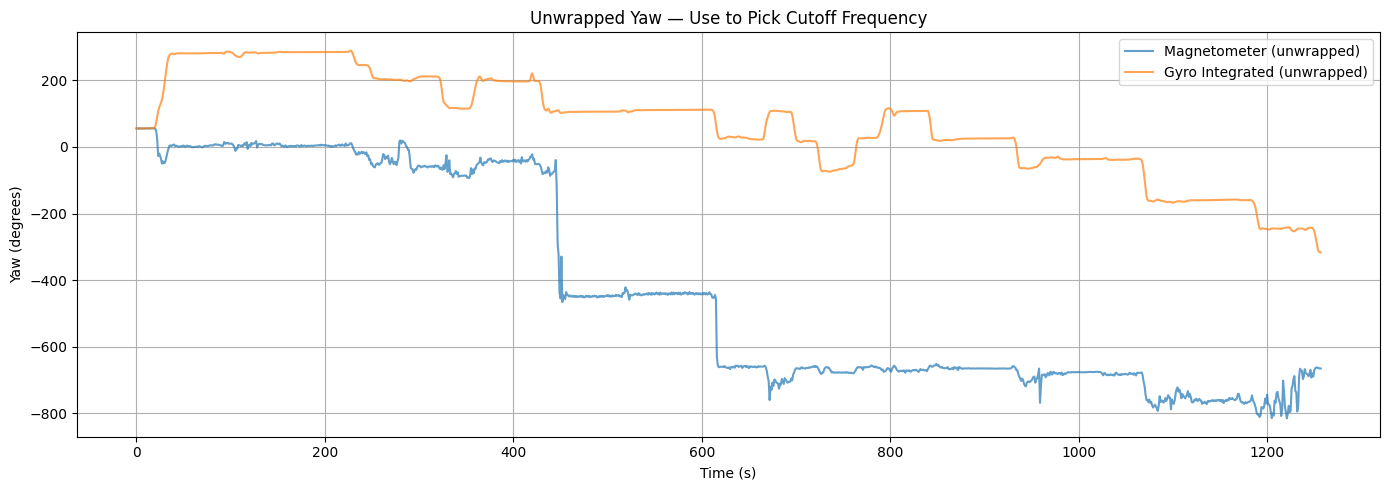

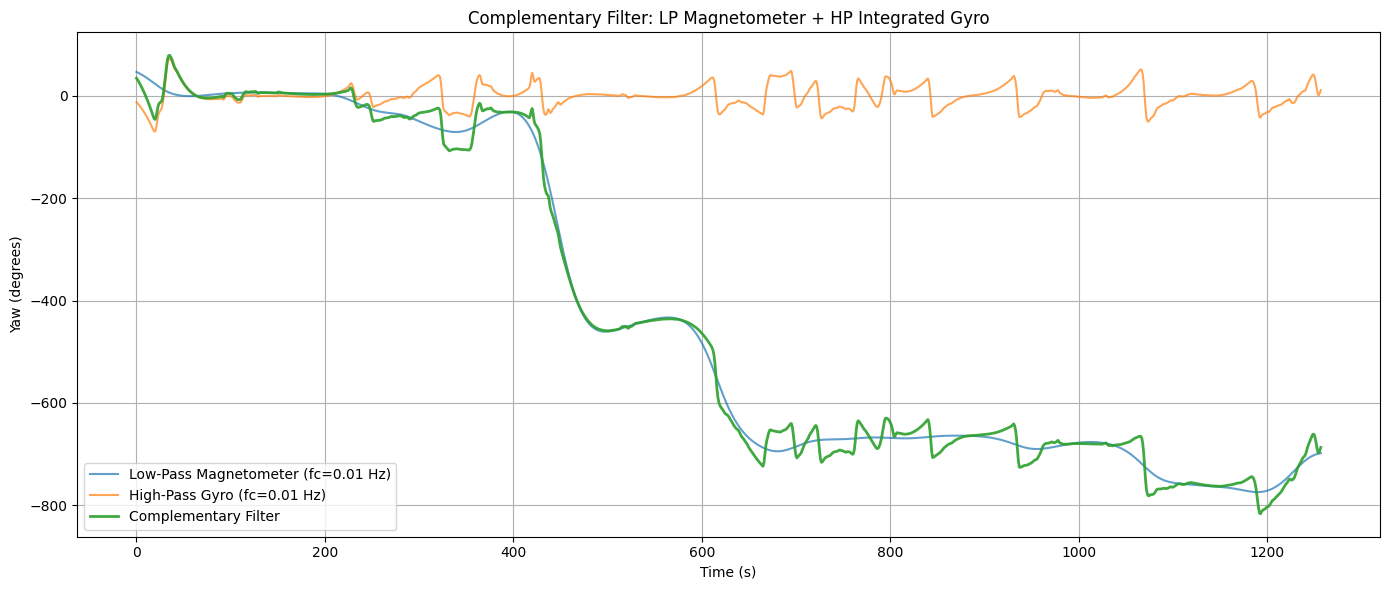

In [76]:
from scipy import integrate, signal

# --- Step 1: Gyro Integration ---
from scipy import integrate, signal

# --- Step 1: Gyro Integration (with bias removal) ---
time = df_drive['time_s'].values
dt_avg = np.mean(np.diff(time))
fs = 1.0 / dt_avg

# Remove gyro bias using first 10 seconds of stationary data
bias_samples = df_drive['time_s'] < 10
gyro_z_bias = df_drive.loc[bias_samples, 'gyro_z'].mean()
print(f"Gyro Z bias: {gyro_z_bias:.6f} rad/s ({np.degrees(gyro_z_bias):.4f} deg/s)")

gyro_z_debiased = -np.degrees(df_drive['gyro_z'].values - gyro_z_bias)

yaw_gyro = integrate.cumulative_trapezoid(gyro_z_debiased, time, initial=0)
yaw_gyro += df_drive['mag_yaw'].iloc[0]

# --- Step 2: Unwrap both yaw signals to remove ±180 jumps ---
yaw_mag_unwrap = np.unwrap(np.radians(df_drive['mag_yaw'].values))
yaw_mag_unwrap = np.degrees(yaw_mag_unwrap)

yaw_gyro_unwrap = np.unwrap(np.radians(yaw_gyro))
yaw_gyro_unwrap = np.degrees(yaw_gyro_unwrap)

# --- Step 3: Choose cutoff frequency ---
# Plot both to help pick a reasonable cutoff
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, yaw_mag_unwrap, label='Magnetometer (unwrapped)', alpha=0.7)
ax.plot(time, yaw_gyro_unwrap, label='Gyro Integrated (unwrapped)', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw (degrees)')
ax.set_title('Unwrapped Yaw — Use to Pick Cutoff Frequency')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Step 4: Butterworth Low-Pass and High-Pass Filters ---
fc = 0.01
order = 2
wn = fc / (fs / 2)

# Low-pass for magnetometer
b_lp, a_lp = signal.butter(order, wn, btype='low')
yaw_mag_lp = signal.filtfilt(b_lp, a_lp, yaw_mag_unwrap)

# High-pass for gyro — use yaw_gyro directly, NOT unwrapped
b_hp, a_hp = signal.butter(order, wn, btype='high')
yaw_gyro_hp = signal.filtfilt(b_hp, a_hp, yaw_gyro_unwrap)

# Complementary filter
yaw_complementary = yaw_mag_lp + yaw_gyro_hp


# --- Step 6: Plot all three together ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time, yaw_mag_lp, label=f'Low-Pass Magnetometer (fc={fc} Hz)', alpha=0.7)
ax.plot(time, yaw_gyro_hp, label=f'High-Pass Gyro (fc={fc} Hz)', alpha=0.7)
ax.plot(time, yaw_complementary, label='Complementary Filter', linewidth=2, alpha=0.9)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw (degrees)')
ax.set_title('Complementary Filter: LP Magnetometer + HP Integrated Gyro')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('images/complementary_filter_yaw.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for later use
df_drive['yaw_gyro'] = yaw_gyro_unwrap
df_drive['yaw_comp'] = yaw_complementary

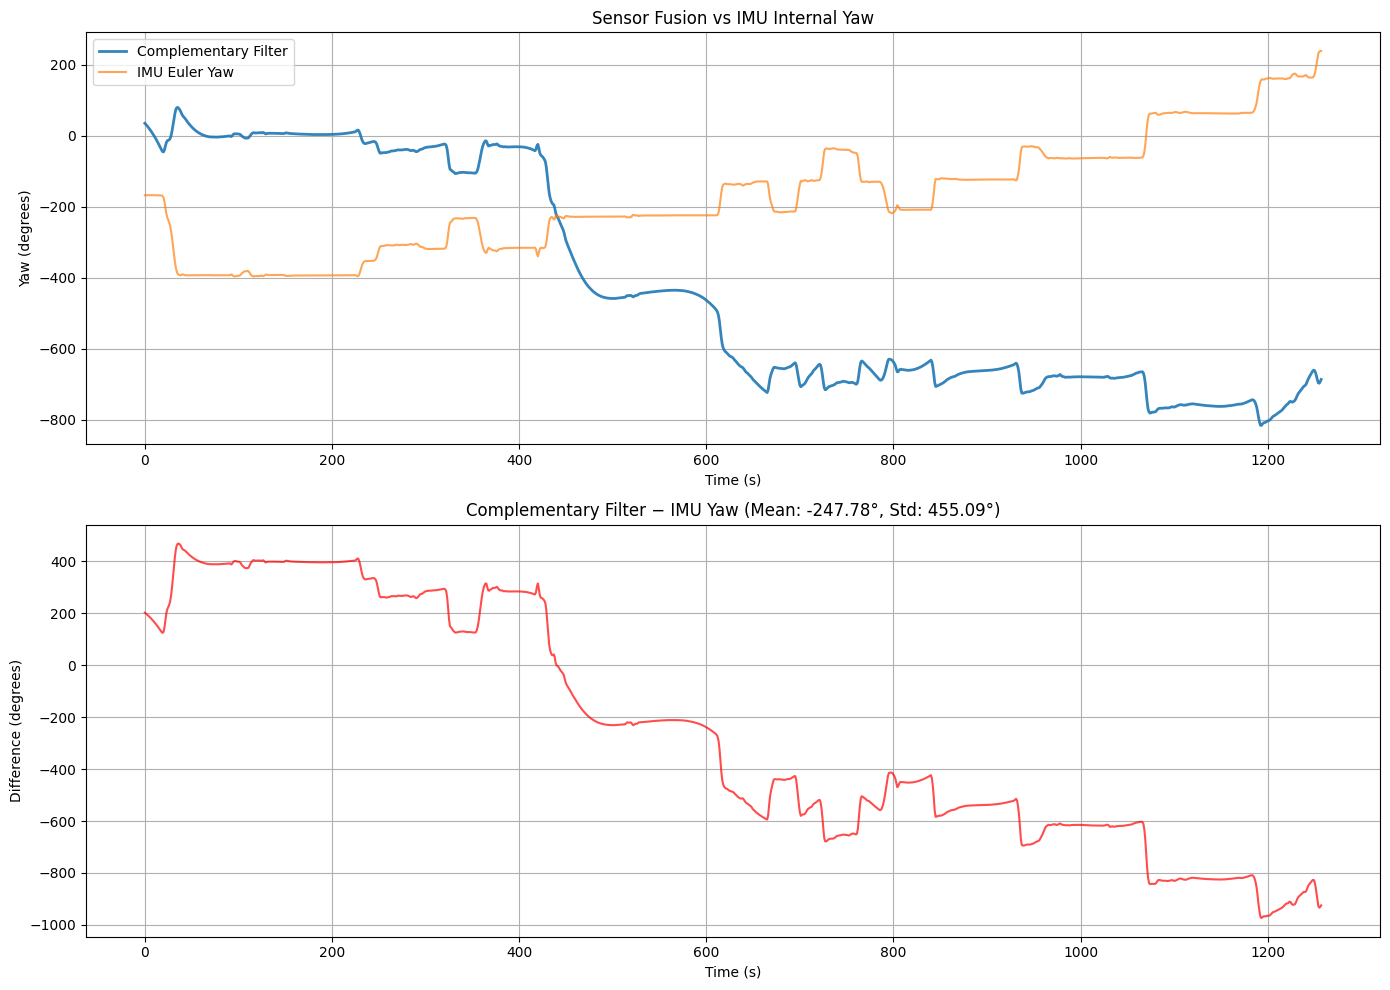

Mean difference: -247.78°
Std deviation:   455.09°
Max difference:  973.69°


In [73]:
# --- Unwrap IMU Euler yaw for comparison ---
yaw_imu_unwrap = np.unwrap(np.radians(df_drive['imu_yaw'].values))
yaw_imu_unwrap = np.degrees(yaw_imu_unwrap)

# --- Plot: Complementary Filter vs IMU Euler Yaw ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: overlay both
axes[0].plot(time, yaw_complementary, label='Complementary Filter', linewidth=2, alpha=0.9)
axes[0].plot(time, yaw_imu_unwrap, label='IMU Euler Yaw', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Yaw (degrees)')
axes[0].set_title('Sensor Fusion vs IMU Internal Yaw')
axes[0].legend()
axes[0].grid(True)

# Bottom: difference between the two
diff = yaw_complementary - yaw_imu_unwrap
axes[1].plot(time, diff, color='red', alpha=0.7)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Difference (degrees)')
axes[1].set_title(f'Complementary Filter − IMU Yaw (Mean: {np.mean(diff):.2f}°, Std: {np.std(diff):.2f}°)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('images/comp_filter_vs_imu_yaw.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean difference: {np.mean(diff):.2f}°")
print(f"Std deviation:   {np.std(diff):.2f}°")
print(f"Max difference:  {np.max(np.abs(diff)):.2f}°")